In [2]:
%cd NISP-Dataset/Hindi_master

/data/himanshu/NISP-Dataset/Hindi_master


/home/himanshu/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import os
dataset_path = '/data/himanshu/NISP-Dataset/Hindi_master'  # Update this path as needed
os.chdir(dataset_path)

In [4]:
import pandas as pd

# Define the path to the speaker info file (adjust if necessary)
spkr_info_path = '../total_spkrinfo.list'
spkr_columns = ['Speaker_ID', 'Gender', 'Mother_Tongue', 'Height_cm',
                'Shoulder_size_cm', 'Waist_size_cm', 'Weight_kg', 'Age_y',
                'Native_State', 'Native_District']

# Load the speaker info into a DataFrame
spkr_info_df = pd.read_csv(spkr_info_path, sep=' ', names=spkr_columns)
spkr_info_df = spkr_info_df.drop(index=0)
print("Speaker Metadata (first 5 rows):")
print(spkr_info_df.head())

Speaker Metadata (first 5 rows):
  Speaker_ID  Gender Mother_Tongue Height_cm Shoulder_size_cm Waist_size_cm  \
1   Hin_0001  Female         Hindi       163               40          89.5   
2   Hin_0002  Female         Hindi     154.5             36.5            72   
3   Hin_0003    Male         Hindi     167.5             40.5            78   
4   Hin_0004    Male         Hindi       176               43          91.5   
5   Hin_0005  Female         Hindi       153             40.5            96   

  Weight_kg  Age_y    Native_State Native_District  
1      58.5  24.24       Rajasthan          Jaipur  
2      50.9  26.06  Madhya_Pradesh          Indore  
3      56.6  21.51         Haryana       Faridabad  
4      77.6  21.09    Chhattisgarh        Bilaspur  
5      80.2  27.39   Uttar_Pradesh    Kanpur_Nagar  


In [5]:
import os

In [6]:
import glob

In [7]:
# Define the folder containing merged audio files
audio_folder = "../Merged_Audio"

# List all .wav files in the merged folder
audio_files = glob.glob(os.path.join(audio_folder, "*.wav"))

# Build a list to store audio file information
audio_data = []
for file_path in audio_files:
    file_name = os.path.basename(file_path)
    # Expected filename format: Hin_0067_Hin_m_0014.wav
    parts = file_name.split('_')
    if len(parts) >= 2:
        # Construct the full speaker ID from the first two tokens, e.g., "Hin_0067"
        speaker_id_full = f"{parts[0]}_{parts[1]}"

        audio_data.append({
            'Speaker_ID': speaker_id_full,

            'File_Path': file_path
        })
    else:
        print("Unexpected filename format:", file_name)

# Create a DataFrame from the audio data
audio_df = pd.DataFrame(audio_data)
print("Audio DataFrame (first 5 rows):")
print(audio_df.head())

Audio DataFrame (first 5 rows):
  Speaker_ID                                File_Path
0   Hin_0092  ../Merged_Audio/Hin_0092_Hin_f_0008.wav
1   Hin_0077  ../Merged_Audio/Hin_0077_Eng_f_7341.wav
2   Hin_0093  ../Merged_Audio/Hin_0093_Hin_f_0023.wav
3   Hin_0020  ../Merged_Audio/Hin_0020_Eng_m_5447.wav
4   Hin_0013  ../Merged_Audio/Hin_0013_Eng_m_5222.wav


In [8]:
audio_df['Speaker_ID'] = audio_df['Speaker_ID'].astype(str)
spkr_info_df['Speaker_ID'] = spkr_info_df['Speaker_ID'].astype(str)


merged_df = pd.merge(audio_df, spkr_info_df[['Speaker_ID', 'Native_State']],
                     on='Speaker_ID', how='left')

# Select only the desired columns: the audio file path and the corresponding Native_State.
final_df = merged_df[['File_Path', 'Speaker_ID', 'Native_State']]
print("Final Dataset (first 5 rows):")
print(final_df.head())

Final Dataset (first 5 rows):
                                 File_Path Speaker_ID   Native_State
0  ../Merged_Audio/Hin_0092_Hin_f_0008.wav   Hin_0092  Uttar_Pradesh
1  ../Merged_Audio/Hin_0077_Eng_f_7341.wav   Hin_0077    Maharashtra
2  ../Merged_Audio/Hin_0093_Hin_f_0023.wav   Hin_0093    Maharashtra
3  ../Merged_Audio/Hin_0020_Eng_m_5447.wav   Hin_0020  Uttar_Pradesh
4  ../Merged_Audio/Hin_0013_Eng_m_5222.wav   Hin_0013          Bihar


In [9]:
df= final_df
df.head()

,File_Path,Speaker_ID,Native_State
0,../Merged_Audio/Hin_0092_Hin_f_0008.wav,Hin_0092,Uttar_Pradesh
1,../Merged_Audio/Hin_0077_Eng_f_7341.wav,Hin_0077,Maharashtra
2,../Merged_Audio/Hin_0093_Hin_f_0023.wav,Hin_0093,Maharashtra
3,../Merged_Audio/Hin_0020_Eng_m_5447.wav,Hin_0020,Uttar_Pradesh
4,../Merged_Audio/Hin_0013_Eng_m_5222.wav,Hin_0013,Bihar


In [10]:
pip install imblearn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
import os
import pandas as pd
import random
import librosa
import numpy as np
import soundfile as sf
from collections import Counter
from imblearn.over_sampling import RandomOverSampler

In [12]:
state_counts = df["Native_State"].value_counts()
print("Original Class Distribution:\n", state_counts)

Original Class Distribution:
 Native_State
Uttar_Pradesh       1579
Rajasthan            971
Madhya_Pradesh       926
Delhi                788
Maharashtra          749
Bihar                626
Uttarakhand          320
Chhattisgarh         306
Haryana              294
Karnataka            220
Jharkhand            155
West_Bengal          154
Gujarat              151
Jammu_&_Kashmir      150
Odisha               150
Panjab                76
Himachal_Pradesh      76
Andhra_Pradesh        75
Meghalaya             73
Name: count, dtype: int64


In [13]:
# Compute Mean
mean_value = np.mean(state_counts)

# Compute Median
median_value = np.median(state_counts)

print(f"Mean Class Size: {mean_value:.2f}")
print(f"Median Class Size: {median_value}")

Mean Class Size: 412.58
Median Class Size: 220.0


In [14]:
# Define balancing thresholds
TARGET_COUNT = 350  # Set target samples per state

In [15]:
pip install nlpaug

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 KB 3.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [15]:
import os
import random
import pandas as pd
import librosa
import soundfile as sf
import nlpaug.augmenter.audio as naa

In [16]:
# Step 1: Undersampling Majority Classes
def undersample(df, target_count):
    df_majority = df[df["Native_State"].map(state_counts) > target_count]
    df_minority = df[df["Native_State"].map(state_counts) <= target_count]
    
    # Randomly sample from majority class
    df_majority_sampled = df_majority.groupby("Native_State").apply(lambda x: x.sample(n=target_count, random_state=42))
    
    return pd.concat([df_majority_sampled, df_minority])

In [17]:
df_balanced = undersample(df, TARGET_COUNT)
print("After Undersampling:\n", df_balanced["Native_State"].value_counts())

After Undersampling:
 Native_State
Bihar               350
Delhi               350
Madhya_Pradesh      350
Maharashtra         350
Rajasthan           350
Uttar_Pradesh       350
Uttarakhand         320
Chhattisgarh        306
Haryana             294
Karnataka           220
Jharkhand           155
West_Bengal         154
Gujarat             151
Odisha              150
Jammu_&_Kashmir     150
Himachal_Pradesh     76
Panjab               76
Andhra_Pradesh       75
Meghalaya            73
Name: count, dtype: int64


/tmp/ipykernel_3058354/1930286831.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_majority_sampled = df_majority.groupby("Native_State").apply(lambda x: x.sample(n=target_count, random_state=42))


In [18]:
def augment_audio_vtlp(file_path, output_dir, sr=16000, augment_count=3):
    audio, _ = librosa.load(file_path, sr=sr)
    vtlp_aug = naa.VtlpAug(sampling_rate=sr, zone=(0.2, 0.8), coverage=1.0, factor=(0.9, 1.1), fhi=4800)
    
    augmented_files = []
    for i in range(augment_count):
        augmented_audio = vtlp_aug.augment(audio)
        
        # Fix 1: Ensure 1D array
        augmented_audio = np.asarray(augmented_audio).squeeze()
        
        # Fix 2: Peak normalization
        peak = np.max(np.abs(augmented_audio))
        if peak > 0:
            augmented_audio /= peak

        os.makedirs(output_dir, exist_ok=True)
        file_name = os.path.basename(file_path).replace(".wav", f"_vtlp_aug{i}.wav")
        output_path = os.path.join(output_dir, file_name)
        
        # Fix 3: Specify PCM_16 subtype
        sf.write(output_path, augmented_audio, sr, subtype='PCM_16')
        
        augmented_files.append(output_path)
    
    return augmented_files

In [19]:
import os
import pandas as pd

# Ensure you already have augment_audio_vtlp defined as discussed earlier
# from augment_script import augment_audio_vtlp  # if you're importing it from another file

# Define your target count
TARGET_COUNT = 350  # example target, set this to your actual class balancing threshold

# Identify minority classes
minority_states = df_balanced["Native_State"].value_counts()[df_balanced["Native_State"].value_counts() < TARGET_COUNT].index.tolist()
output_dir = "augmented_audio_vtlp"
os.makedirs(output_dir, exist_ok=True)

augmented_data = []

# Loop through each minority class
for state in minority_states:
    state_df = df_balanced[df_balanced["Native_State"] == state]
    files_needed = TARGET_COUNT - len(state_df)
    
    for _, row in state_df.iterrows():
        # VTLP-based augmentation
        new_files = augment_audio_vtlp(row["File_Path"], output_dir, augment_count=3)
        
        for file in new_files:
            augmented_data.append({
                "File_Path": file,
                "Speaker_ID": row["Speaker_ID"],
                "Native_State": state
            })
        
        files_needed -= len(new_files)
        if files_needed <= 0:
            break

# Combine original and augmented data
df_augmented = pd.DataFrame(augmented_data)
df_final = pd.concat([df_balanced, df_augmented], ignore_index=True)

# Show final distribution
print("Final Class Distribution:\n", df_final["Native_State"].value_counts())

Final Class Distribution:
 Native_State
West_Bengal         352
Karnataka           352
Gujarat             352
Odisha              351
Jammu_&_Kashmir     351
Chhattisgarh        351
Haryana             351
Madhya_Pradesh      350
Delhi               350
Bihar               350
Maharashtra         350
Jharkhand           350
Uttarakhand         350
Rajasthan           350
Uttar_Pradesh       350
Himachal_Pradesh    304
Panjab              304
Andhra_Pradesh      300
Meghalaya           292
Name: count, dtype: int64


In [20]:
df_final.describe()

,File_Path,Speaker_ID,Native_State
count,6460,6460,6460
unique,6460,103,19
top,augmented_audio_vtlp/Hin_0082_Eng_m_7467_vtlp_...,Hin_0033,West_Bengal
freq,1,304,352


In [21]:

# Reset the index if it's a problem
df_final = df_final.reset_index(drop=True)

# Make sure column names don't have spaces or special characters
print(df_final.columns)

# Try viewing with to_string() method for cleaner output
print(df_final.head().to_string())

# Or display as HTML in Jupyter
from IPython.display import display
display(df_final.head())

Index(['File_Path', 'Speaker_ID', 'Native_State'], dtype='object')
                                 File_Path Speaker_ID Native_State
0  ../Merged_Audio/Hin_0014_Hin_m_0035.wav   Hin_0014        Bihar
1  ../Merged_Audio/Hin_0052_Eng_m_0001.wav   Hin_0052        Bihar
2  ../Merged_Audio/Hin_0052_Eng_m_0003.wav   Hin_0052        Bihar
3  ../Merged_Audio/Hin_0029_Hin_m_0032.wav   Hin_0029        Bihar
4  ../Merged_Audio/Hin_0052_Eng_m_6490.wav   Hin_0052        Bihar


,File_Path,Speaker_ID,Native_State
0,../Merged_Audio/Hin_0014_Hin_m_0035.wav,Hin_0014,Bihar
1,../Merged_Audio/Hin_0052_Eng_m_0001.wav,Hin_0052,Bihar
2,../Merged_Audio/Hin_0052_Eng_m_0003.wav,Hin_0052,Bihar
3,../Merged_Audio/Hin_0029_Hin_m_0032.wav,Hin_0029,Bihar
4,../Merged_Audio/Hin_0052_Eng_m_6490.wav,Hin_0052,Bihar


In [22]:
df_final.shape


(6460, 3)

In [23]:
codes, uniques = pd.factorize(df_final['Native_State'])

df_final['Native_State_Code'] = codes

mapping = dict(enumerate(uniques))
display(mapping)

{0: 'Bihar',
 1: 'Delhi',
 2: 'Madhya_Pradesh',
 3: 'Maharashtra',
 4: 'Rajasthan',
 5: 'Uttar_Pradesh',
 6: 'Haryana',
 7: 'Uttarakhand',
 8: 'Chhattisgarh',
 9: 'Gujarat',
 10: 'Andhra_Pradesh',
 11: 'Meghalaya',
 12: 'Karnataka',
 13: 'West_Bengal',
 14: 'Jammu_&_Kashmir',
 15: 'Panjab',
 16: 'Jharkhand',
 17: 'Odisha',
 18: 'Himachal_Pradesh'}

In [24]:
import os
import numpy as np
import pandas as pd
import librosa
import scipy.signal as signal
import soundfile as sf

In [25]:
def extract_salient_segments(audio, sr, num_segments=1, segment_duration=3.0):
    """
    Extracts `num_segments` segments each of `segment_duration` seconds from the audio
    based on points of maximum spectral change.
    """
    hop_length = 512
    n_fft = 2048

    # Compute the magnitude spectrogram
    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop_length))

    # Compute spectral flux: change in the spectrum between successive frames
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0))
    flux = np.concatenate(([0], flux))  # Align flux with frames

    # Detect peaks in the spectral flux that are above the average flux level
    peaks, _ = signal.find_peaks(flux, height=np.mean(flux))
    if len(peaks) == 0:
        print("No significant peaks found in audio.")
        return []

    # Sort the detected peaks by flux strength (largest first)
    sorted_peaks = peaks[np.argsort(flux[peaks])][::-1]

    seg_length_samples = int(segment_duration * sr)
    segments = []

    # Extract segments centered around the strongest peaks
    for peak in sorted_peaks[:num_segments]:
        peak_time = librosa.frames_to_time(peak, sr=sr, hop_length=hop_length)
        center_sample = int(peak_time * sr)
        start = max(0, center_sample - seg_length_samples // 2)
        end = start + seg_length_samples
        if end > len(audio):
            end = len(audio)
            start = max(0, end - seg_length_samples)
        segments.append(audio[start:end])

    return segments

In [26]:
def process_dataframe(df, output_dir="extracted_segments", output_db_csv="extracted_segments_db.csv"):
    """
    For each audio file in the DataFrame:
      - If its duration is at least 3 seconds, extract 1 segments 
        based on spectral flux.
      - Save the extracted segments as WAV files.
      - Record the extracted file paths along with the corresponding native state in a new CSV database.
    """
    # Create the output directory if it doesn't exist.
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    records = []

    # Process each row in the DataFrame.
    for index, row in df.iterrows():
        file_path = row["File_Path"]
        speaker_id = row["Speaker_ID"]
        native_state = row["Native_State"]
       

        if not os.path.exists(file_path):
            print(f"File not found: {file_path}")
            continue

        # Load the audio file with its original sample rate. This line was incorrectly indented.
        audio, sr = librosa.load(file_path, sr=None)

        # Get the duration of the audio in seconds.
        duration = librosa.get_duration(y=audio, sr=sr)


        # Only process if the duration is at least 3 seconds.
        if duration < 3.0:
            continue

        # Extract 1 segments, each 3 seconds long.
        segments = extract_salient_segments(audio,sr, num_segments=1, segment_duration=3.0)

        base_name = os.path.splitext(os.path.basename(file_path))[0]
        for seg_index, segment in enumerate(segments):
            # Save each segment as a WAV file.
            output_file = os.path.join(output_dir, f"{base_name}_seg{seg_index+1}.wav")
            sf.write(output_file, segment, sr)

            # Record the extracted file path and the native state.
            records.append({
                "Extracted_File_Path": output_file,
                "Native_State": native_state
            }) # Blank line for clarity between files.

    # Create a new DataFrame from the records and save it as a CSV file.
    db_df = pd.DataFrame(records)
    db_df.to_csv(output_db_csv, index=False)
    print(f"Database saved to {output_db_csv}")

In [27]:
process_dataframe(df_final)

Database saved to extracted_segments_db.csv


In [28]:
import pandas as pd

# Load the newly created CSV into a DataFrame
df = pd.read_csv("extracted_segments_db.csv")

# Print the column names
print("Columns:", df.columns.tolist())

# Print the number of rows and columns
print("Shape:", df.shape)

# Print the first 5 rows to see a sample of the data
print(df.head(50))

Columns: ['Extracted_File_Path', 'Native_State']
Shape: (6456, 2)
                                Extracted_File_Path Native_State
0   extracted_segments/Hin_0014_Hin_m_0035_seg1.wav        Bihar
1   extracted_segments/Hin_0052_Eng_m_0001_seg1.wav        Bihar
2   extracted_segments/Hin_0052_Eng_m_0003_seg1.wav        Bihar
3   extracted_segments/Hin_0029_Hin_m_0032_seg1.wav        Bihar
4   extracted_segments/Hin_0052_Eng_m_6490_seg1.wav        Bihar
5   extracted_segments/Hin_0016_Eng_m_5320_seg1.wav        Bihar
6   extracted_segments/Hin_0056_Hin_m_0001_seg1.wav        Bihar
7   extracted_segments/Hin_0014_Hin_m_0019_seg1.wav        Bihar
8   extracted_segments/Hin_0014_Eng_m_5251_seg1.wav        Bihar
9   extracted_segments/Hin_0052_Eng_m_6503_seg1.wav        Bihar
10  extracted_segments/Hin_0060_Hin_m_0039_seg1.wav        Bihar
11  extracted_segments/Hin_0060_Eng_m_6754_seg1.wav        Bihar
12  extracted_segments/Hin_0060_Hin_m_0040_seg1.wav        Bihar
13  extracted_segments/H

In [30]:
df_5_per_state = (
    df.groupby("Native_State", group_keys=False)
      .sample(n=5, random_state=42)
)

print(df_5_per_state)


                                    Extracted_File_Path    Native_State
6140  extracted_segments/Hin_0097_Hin_m_0007_vtlp_au...  Andhra_Pradesh
6203  extracted_segments/Hin_0097_Hin_m_0001_vtlp_au...  Andhra_Pradesh
6089  extracted_segments/Hin_0097_Eng_m_7972_vtlp_au...  Andhra_Pradesh
2226    extracted_segments/Hin_0097_Eng_m_7971_seg1.wav  Andhra_Pradesh
6170  extracted_segments/Hin_0097_Eng_m_7977_vtlp_au...  Andhra_Pradesh
...                                                 ...             ...
4842  extracted_segments/Hin_0008_Hin_m_0013_vtlp_au...     West_Bengal
2748    extracted_segments/Hin_0008_Hin_m_0009_seg1.wav     West_Bengal
4853  extracted_segments/Hin_0008_Eng_m_5068_vtlp_au...     West_Bengal
3112    extracted_segments/Hin_0008_Eng_m_5044_seg1.wav     West_Bengal
2295    extracted_segments/Hin_0008_Eng_m_5050_seg1.wav     West_Bengal

[95 rows x 2 columns]


In [35]:

with pd.option_context('display.max_colwidth', None):
    display(df_5_per_state)

,Extracted_File_Path,Native_State
6140,extracted_segments/Hin_0097_Hin_m_0007_vtlp_aug2_seg1.wav,Andhra_Pradesh
6203,extracted_segments/Hin_0097_Hin_m_0001_vtlp_aug2_seg1.wav,Andhra_Pradesh
6089,extracted_segments/Hin_0097_Eng_m_7972_vtlp_aug2_seg1.wav,Andhra_Pradesh
2226,extracted_segments/Hin_0097_Eng_m_7971_seg1.wav,Andhra_Pradesh
6170,extracted_segments/Hin_0097_Eng_m_7977_vtlp_aug2_seg1.wav,Andhra_Pradesh
87,extracted_segments/Hin_0060_Eng_m_6741_seg1.wav,Bihar
265,extracted_segments/Hin_0016_Eng_m_5325_seg1.wav,Bihar
260,extracted_segments/Hin_0056_Hin_m_0027_seg1.wav,Bihar
234,extracted_segments/Hin_0016_Eng_m_5314_seg1.wav,Bihar
72,extracted_segments/Hin_0013_Eng_m_5226_seg1.wav,Bihar


In [40]:
from IPython.display import Audio

Audio("extracted_segments/Hin_0042_Eng_m_6194_vtlp_aug0_seg1.wav")


In [31]:
from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
import pandas as pd

In [32]:
# Assuming df is a Pandas DataFrame
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Convert to DatasetDict
ds = DatasetDict(
    {
        "train": Dataset.from_pandas(train_df),
        "validation": Dataset.from_pandas(val_df),
    }
)

In [33]:
model_name = "mispeech/dasheng-base"

In [34]:
from dasheng_model.feature_extraction_dasheng import DashengFeatureExtractor

feature_extractor = DashengFeatureExtractor.from_pretrained(model_name)

In [35]:
from dasheng_model.feature_extraction_dasheng import DashengFeatureExtractor

def preprocess_function(example):
    max_duration = 3
    target_sr = 16000
    desired_length = int(max_duration * target_sr)  # Target number of samples

    # Load and resample the audio
    audio, orig_sr = librosa.load(example['Extracted_File_Path'], sr=48000)
    audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=target_sr)

    # If the audio is shorter than the desired length, repeat (tile) it until it reaches the target length.
    if len(audio) < desired_length:
        # Calculate how many repeats are neede-d.
        num_repeats = int(np.ceil(desired_length / len(audio)))
        audio = np.tile(audio, num_repeats)[:desired_length]
    else:
        # Otherwise, truncate the audio to the desired length.
        audio = audio[:desired_length]

    # Use the feature extractor to process the audio
    inputs = feature_extractor(
        audio,
        sampling_rate=feature_extractor.sampling_rate,
        max_length=desired_length,
        truncation=True,
    )

    # Squeeze extra dimensions if needed
    inputs["input_values"] = inputs["input_values"].squeeze(0)
    return {**inputs, "labels": example['Native_State']}

In [36]:
import librosa
import numpy as np

In [38]:
encoded_dataset = ds.map(
    preprocess_function,
    remove_columns=['Extracted_File_Path', 'Native_State'],  
    batched=False,
    with_indices=False
)


Map:   0%|          | 0/5164 [00:00<?, ? examples/s]

Map:   0%|          | 0/1292 [00:00<?, ? examples/s]

In [39]:
encoded_dataset["validation"][176]

{'__index_level_0__': 1219,
 'input_values': [[-32.46358108520508,
   -26.191213607788086,
   -23.426332473754883,
   -22.050987243652344,
   -21.2655029296875,
   -28.07676124572754,
   -28.544906616210938,
   -21.42892074584961,
   -18.983734130859375,
   -20.72005271911621,
   -27.477453231811523,
   -35.16297912597656,
   -30.799072265625,
   -32.956233978271484,
   -29.9950008392334,
   -27.999492645263672,
   -28.383087158203125,
   -34.79367446899414,
   -40.782073974609375,
   -32.362186431884766,
   -24.112613677978516,
   -24.869977951049805,
   -25.767257690429688,
   -27.691133499145508,
   -30.25069808959961,
   -24.655807495117188,
   -24.258554458618164,
   -21.98712921142578,
   -26.084022521972656,
   -39.90004348754883,
   -49.74385070800781,
   -37.02032470703125,
   -32.896549224853516,
   -30.447914123535156,
   -35.931697845458984,
   -31.27117919921875,
   -30.222251892089844,
   -26.865619659423828,
   -27.703426361083984,
   -29.56092071533203,
   -40.598011016

In [40]:
from transformers import TrainingArguments, Trainer

2025-05-23 18:13:14.969444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748004195.424419 2014763 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748004195.534702 2014763 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748004196.509136 2014763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748004196.509164 2014763 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748004196.509168 2014763 computation_placer.cc:177] computation placer alr

In [41]:
    from dasheng_model.modeling_dasheng import DashengModel

    outputdim = 19
    model = DashengModel.from_pretrained(model_name, outputdim=outputdim, ignore_mismatched_sizes=True)

    model.freeze_encoder()
    model.config.loss = "CrossEntropyLoss"

Some weights of DashengModel were not initialized from the model checkpoint at mispeech/dasheng-base and are newly initialized: ['outputlayer.0.bias', 'outputlayer.0.weight', 'outputlayer.1.bias', 'outputlayer.1.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [42]:
batch_size = 32
args = TrainingArguments(
    f"{model_name}-esc50",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-3,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=1,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=10,
    warmup_ratio=0,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    dataloader_num_workers=2,    # Google Colab suggests setting num_worker=2
    push_to_hub=False,
)

/data/himanshu/new_env/lib/python3.10/site-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [43]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions[0], axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [44]:
trainer = Trainer(
    model,
    args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    tokenizer=feature_extractor,
    compute_metrics=compute_metrics,

)

/tmp/ipykernel_2014763/1451490098.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [46]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.138300,2.157959,0.847523
2,2.110200,2.154388,0.871517
3,2.107300,2.151736,0.862229
4,2.104000,2.144567,0.876161
5,2.102700,2.144016,0.879257
6,2.092000,2.139864,0.883127
7,2.081200,2.141032,0.880031
8,2.087300,2.138275,0.888545
9,2.082900,2.138498,0.888545
10,2.082700,2.138285,0.886997


TrainOutput(global_step=1620, training_loss=2.1018306378965024, metrics={'train_runtime': 365.875, 'train_samples_per_second': 141.141, 'train_steps_per_second': 4.428, 'total_flos': 5.101136446065408e+17, 'train_loss': 2.1018306378965024, 'epoch': 10.0})

In [59]:
trainer.state.epoch

10.0

In [66]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import Trainer

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        logits = predictions[0]
    else:
        logits = predictions
    preds = logits.argmax(axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    accuracy = accuracy_score(labels, preds)
    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    compute_metrics=compute_metrics
)

eval_results = trainer.evaluate()
print(eval_results)


{'eval_loss': 2.138275146484375, 'eval_model_preparation_time': 0.0043, 'eval_accuracy': 0.8885448916408669, 'eval_f1': 0.8892089323533745, 'eval_precision': 0.891093348091231, 'eval_recall': 0.8885448916408669, 'eval_runtime': 8.9406, 'eval_samples_per_second': 144.509, 'eval_steps_per_second': 4.586}


In [67]:
import json

# Print results in a well-formatted way
print(json.dumps(eval_results, indent=4))


{
    "eval_loss": 2.138275146484375,
    "eval_model_preparation_time": 0.0043,
    "eval_accuracy": 0.8885448916408669,
    "eval_f1": 0.8892089323533745,
    "eval_precision": 0.891093348091231,
    "eval_recall": 0.8885448916408669,
    "eval_runtime": 8.9406,
    "eval_samples_per_second": 144.509,
    "eval_steps_per_second": 4.586
}


In [63]:
# Get model predictions on the training dataset
train_outputs = trainer.predict(encoded_dataset["train"])

# Extract logits and true labels
if isinstance(train_outputs.predictions, tuple):
    logits = train_outputs.predictions[0]  # Handle tuple outputs (logits, loss)
else:
    logits = train_outputs.predictions
labels = train_outputs.label_ids

# Convert logits to predicted classes
preds = np.argmax(logits, axis=-1)

In [64]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(labels, preds)
print(f"Training Accuracy: {train_accuracy:.4f}")

Training Accuracy: 0.9413


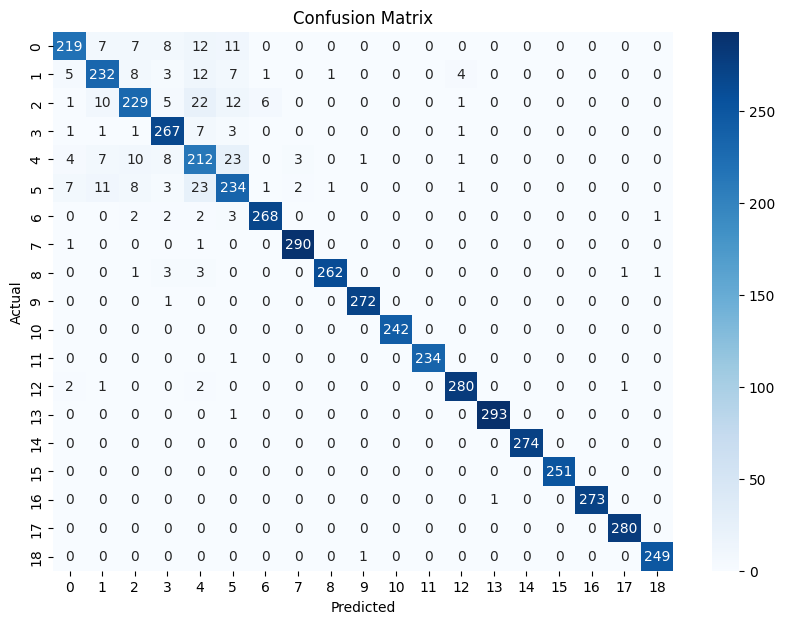

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(labels, preds)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [78]:
trainer.save_model("dialect_classfier")

In [ ]:
trainer = Trainer(model, args, train_dataset, eval_dataset)
trainer.train(resume_from_checkpoint="my_checkpoint")